In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")



from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split, StratifiedKFold,cross_val_score,GridSearchCV

# MACHINE LEARNING MODELS
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# MODEL EVALUATION
# =========================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)


Load the data 

In [3]:
df=pd.read_csv("Bank_Churn.csv")
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


review of dataset

In [4]:
# data description 
df.describe()

#check null values / missing 
df.isnull().sum()

#data info
df.info()

#data data types
df.dtypes

#data shape
df.shape

#target distribution 
df['Exited'].value_counts(normalize=False)

df['Exited'].value_counts(normalize=True)*100

#0 = False / No
#1 = True / Yes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

EDA

In [5]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
#numerical columns and categorical columns

num_col=['CreditScore','Tenure','Balance','NumOfProducts','EstimatedSalary','Age']
cat_col=['Gender','Geography','HasCrCard','IsActiveMember']

Visualization

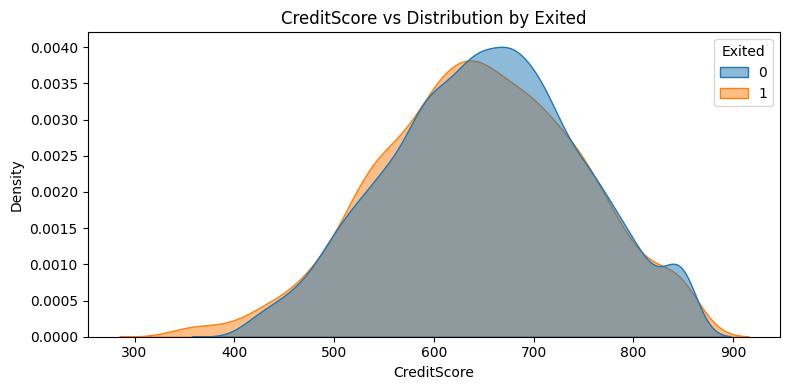

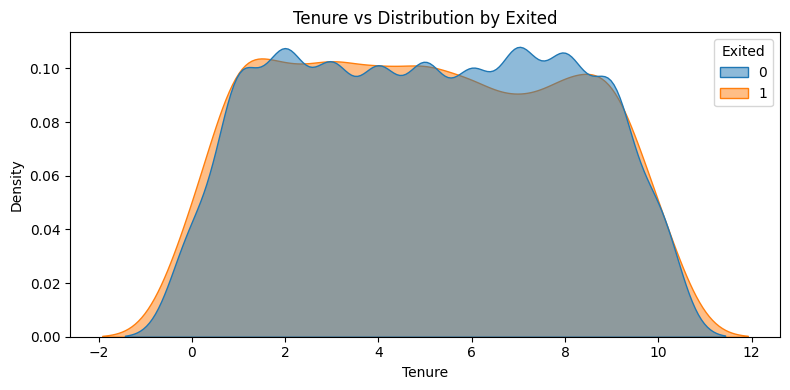

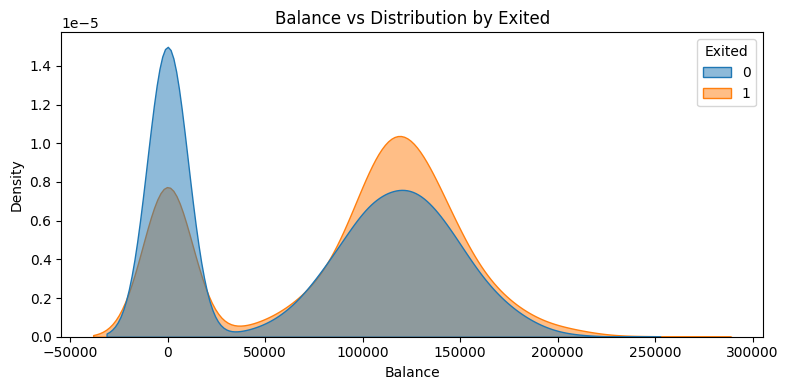

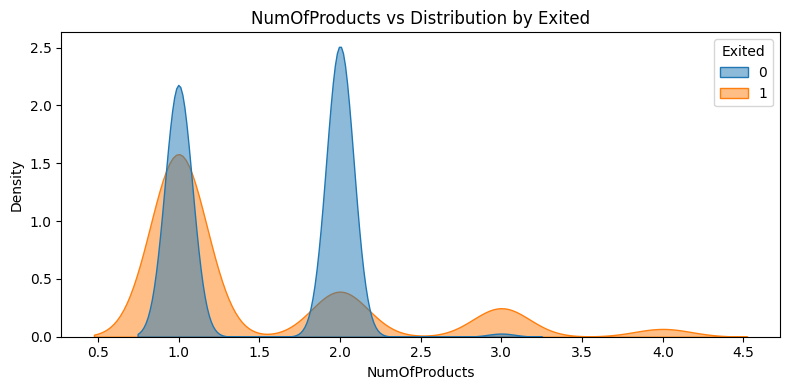

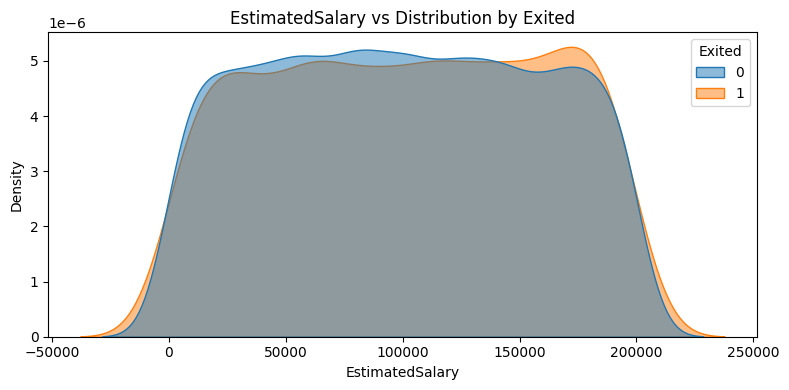

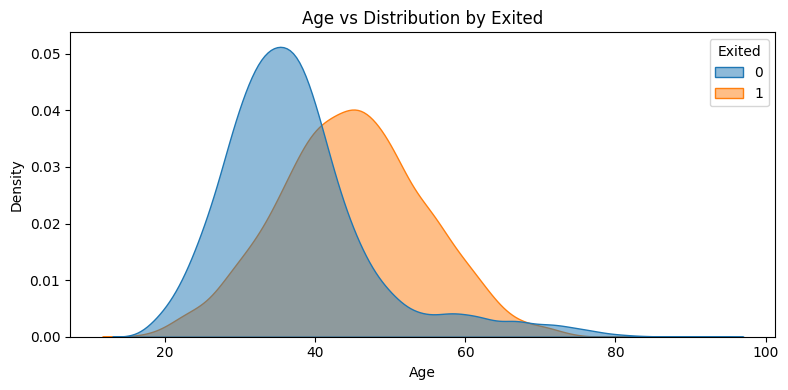

In [7]:
#histogram and KDE

for col in num_col:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df, x=col, hue='Exited',fill=True,alpha=0.5,common_norm=False)
    plt.title(f"{col} vs Distribution by Exited")
    plt.tight_layout()
    plt.show()


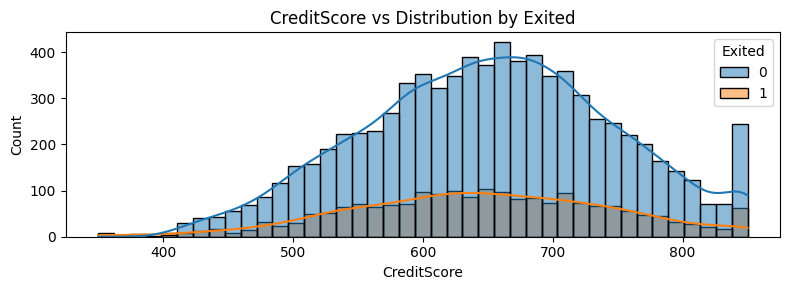

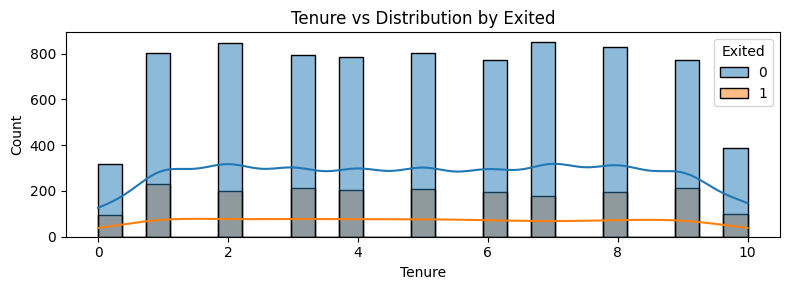

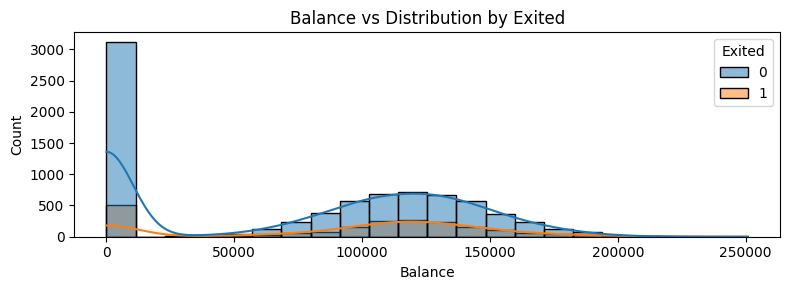

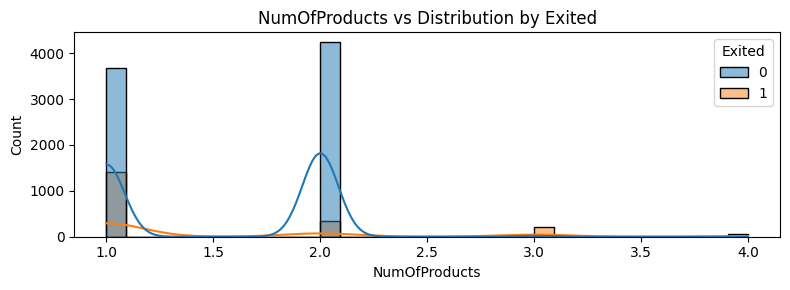

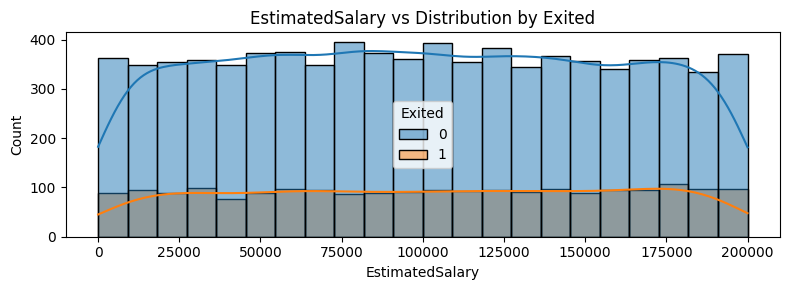

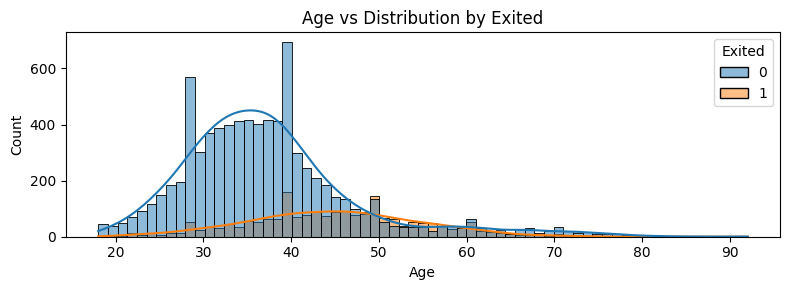

In [8]:
#histogram +KDE
#Use histogram + KDE to see the shape of data.

for col in num_col:
    plt.figure(figsize=(8,3))
    sns.histplot(data=df, x=col,kde=True, hue='Exited',fill=True,alpha=0.5,common_norm=False)
    plt.title(f"{col} vs Distribution by Exited")
    plt.tight_layout()
    plt.show()

### Balance vs Exited

The balance distribution shows that a large number of customers have zero balance, and most of them did not churn. Among customers with balances around 100,000 to 150,000, the number of non-churned customers is higher than churned customers. However, churn is still present in this range, which means balance alone cannot determine whether a customer will exit. It should be analyzed together with other features.


### CreditScore vs Exited

Most customers have credit scores between 550 and 750. Both churned and non-churned customers are distributed across similar credit score ranges. This shows that CreditScore alone does not strongly separate customers who exited from those who stayed. However, it may still help the model when combined with other features.

#### BOX PLOT

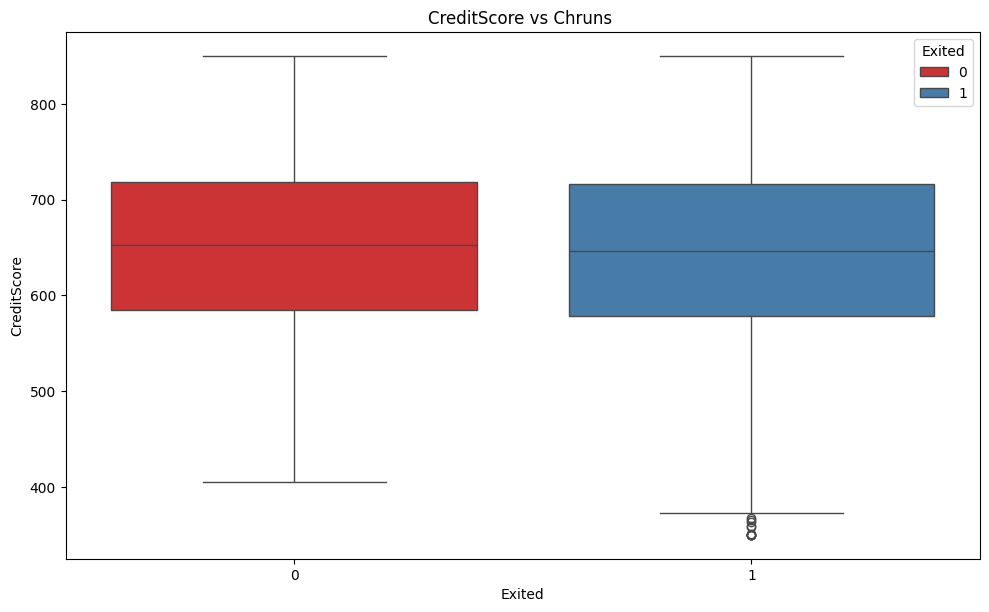

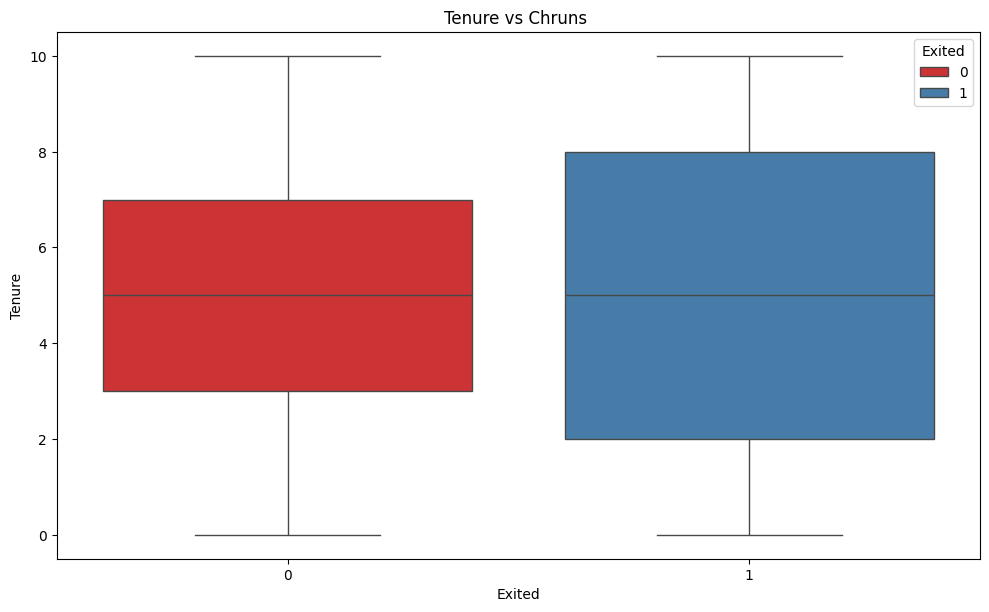

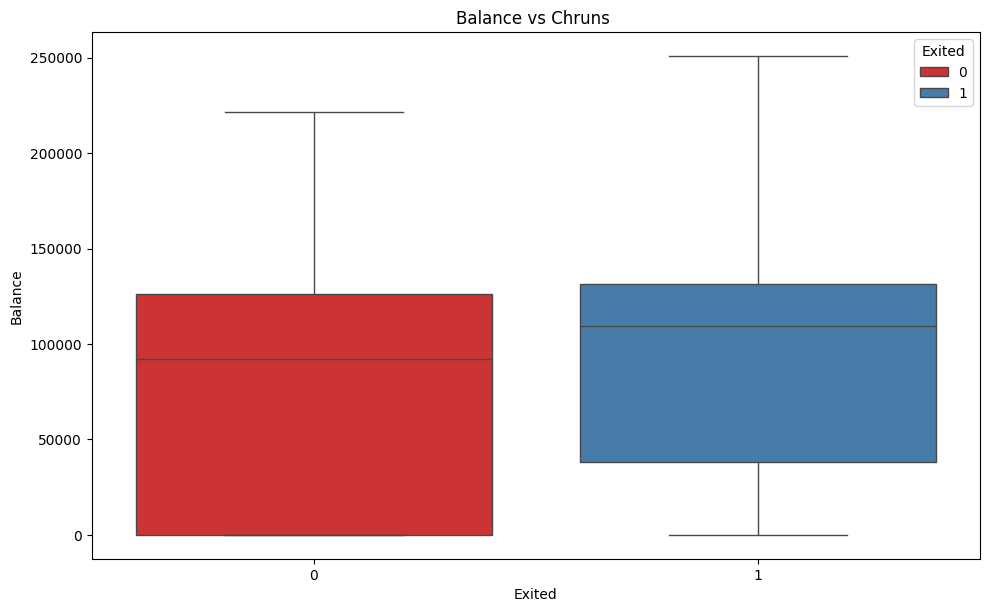

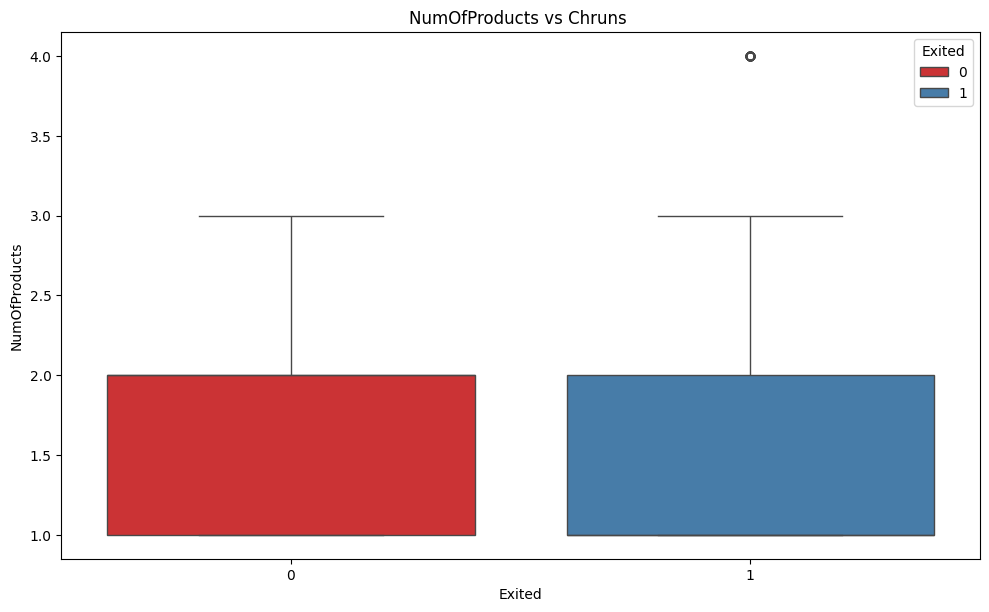

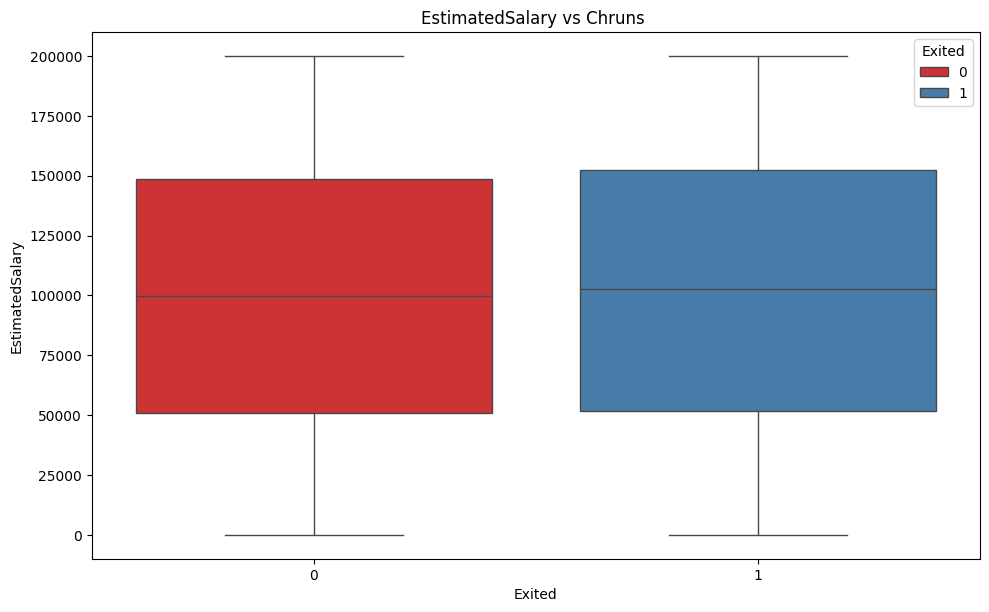

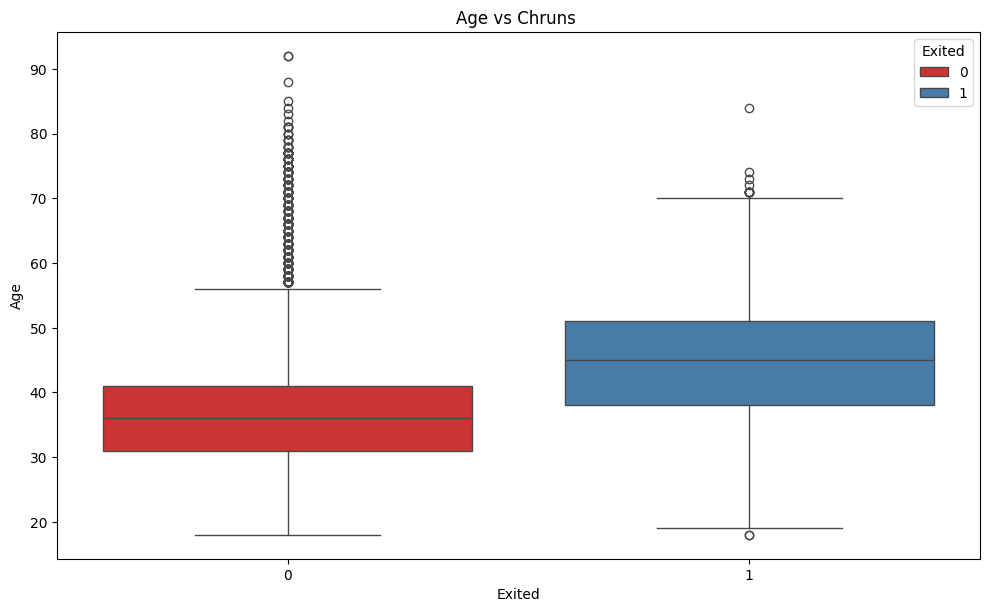

In [9]:
for col in num_col:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x="Exited",y=col,hue="Exited",palette='Set1')
    plt.tight_layout()
    plt.title(f"{col} vs Chruns ")
    plt.show()

### Age vs Exited Boxplot

The Age vs Exited boxplot shows a clear difference between customers who stayed and customers who exited. Customers who exited the bank generally have a higher median age compared to customers who did not exit.

For non-churned customers, the median age is around 36 years, while for churned customers, the median age is around 45 years. This suggests that older customers are more likely to churn than younger customers.

There are also some older outliers in the non-churned group, but the overall pattern shows that age is an important feature for predicting customer churn.

### Box Plot

<function matplotlib.pyplot.show(close=None, block=None)>

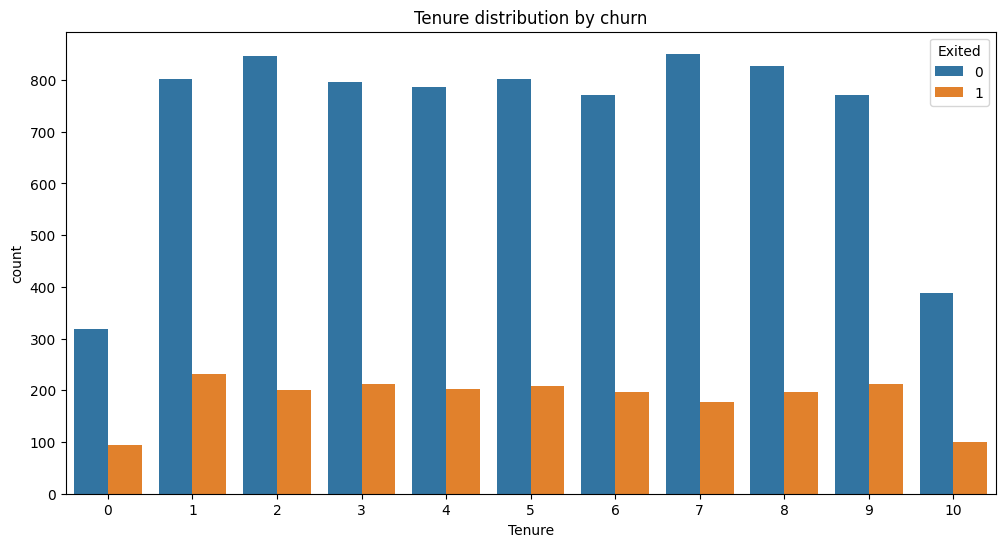

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x="Tenure",hue="Exited")
plt.title("Tenure distribution by churn")
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

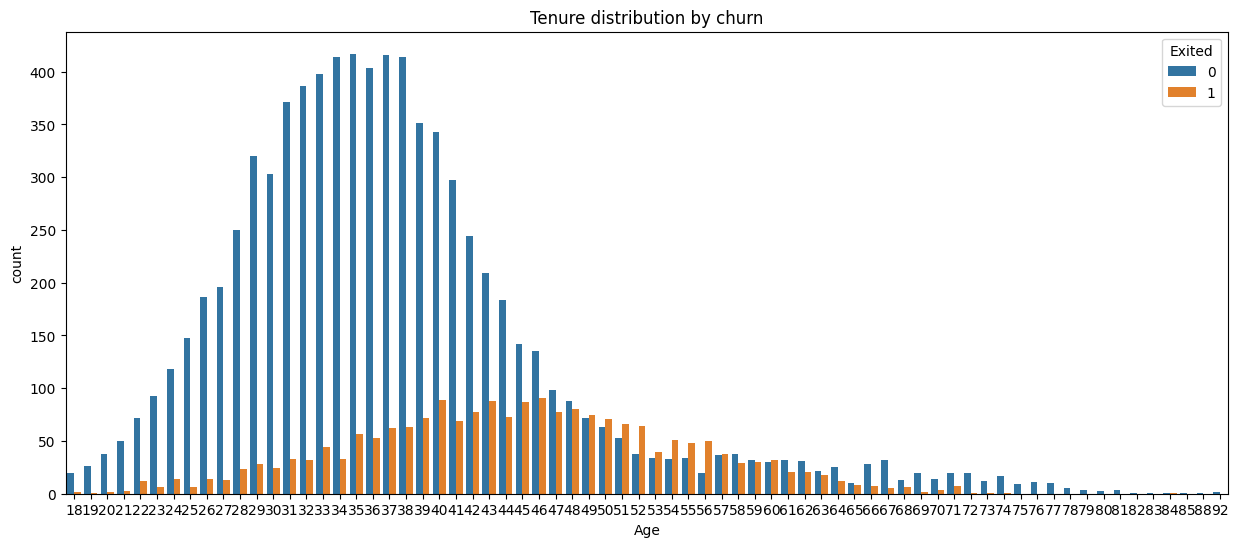

In [11]:
plt.figure(figsize=(15,6))
sns.countplot(data=df,x="Age",hue="Exited")
plt.title("Tenure distribution by churn")
plt.tight_layout
plt.show

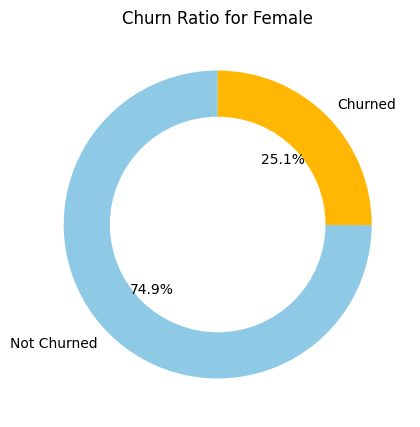

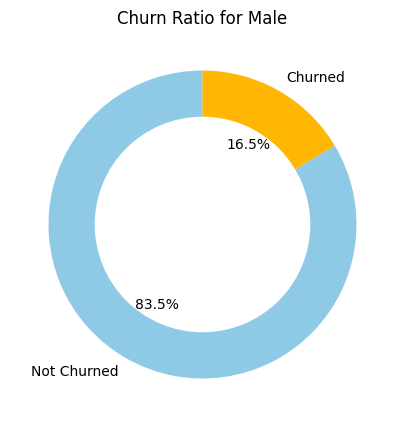

In [12]:
gender_count = df.groupby('Gender')['Exited'].value_counts(normalize=True).unstack().fillna(0)

for gender in gender_count.index:
    plt.figure(figsize=(5, 5))
    
    plt.pie(
        gender_count.loc[gender],
        labels=['Not Churned', 'Churned'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#8ecae6', '#ffb703']
    )
    
    # Donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title(f'Churn Ratio for {gender}')
    plt.show()

### Count plot for categorical data

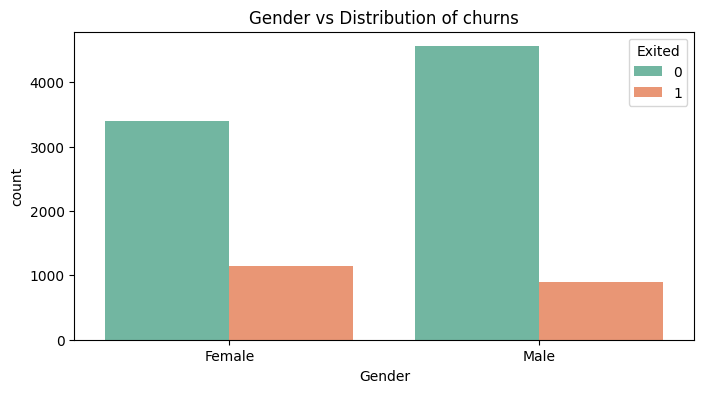

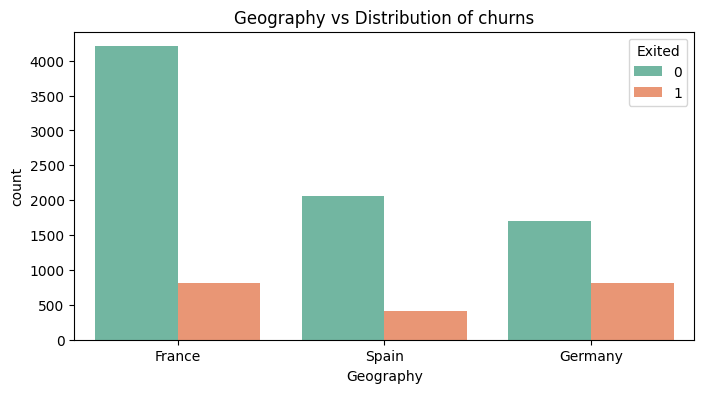

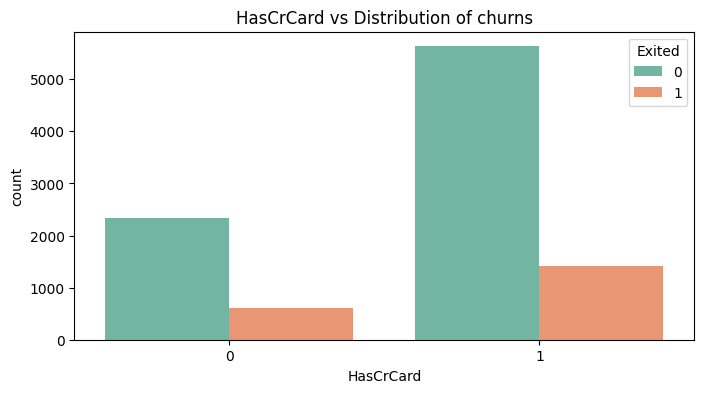

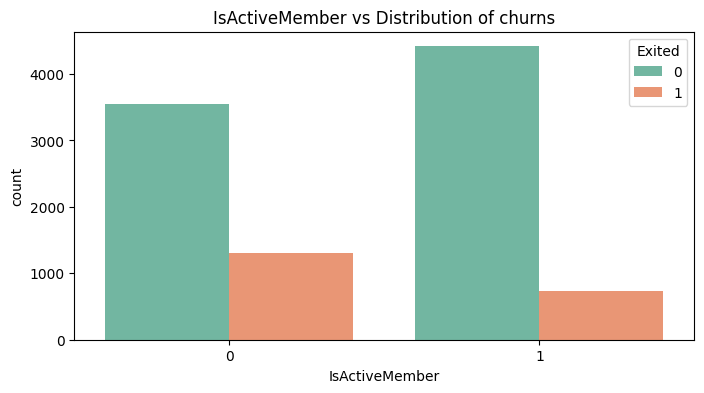

In [13]:
for coll in cat_col:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=coll ,hue="Exited",palette="Set2")
    plt.title(f"{coll} vs Distribution of churns")
    plt.tight_layout
    plt.show()

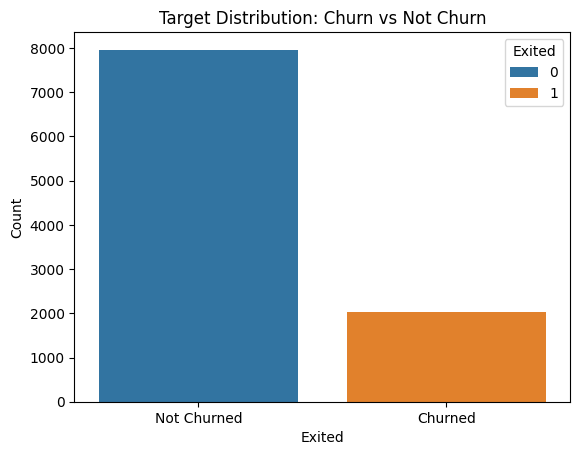

In [14]:
sns.countplot(data=df, x='Exited',hue="Exited")
plt.title('Target Distribution: Churn vs Not Churn')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.show()

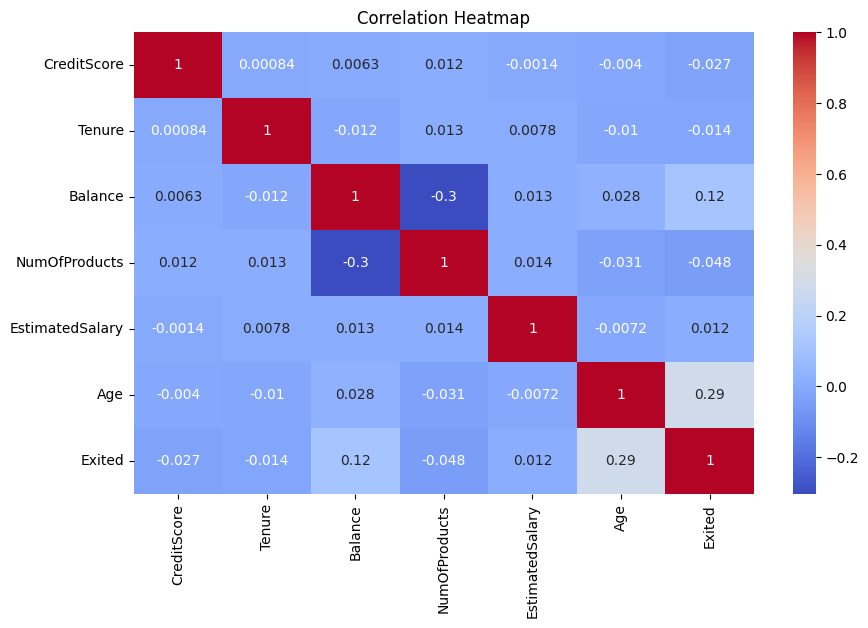

In [15]:
plt.figure(figsize=(10, 6))

sns.heatmap(df[num_col + ['Exited']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Heat Map

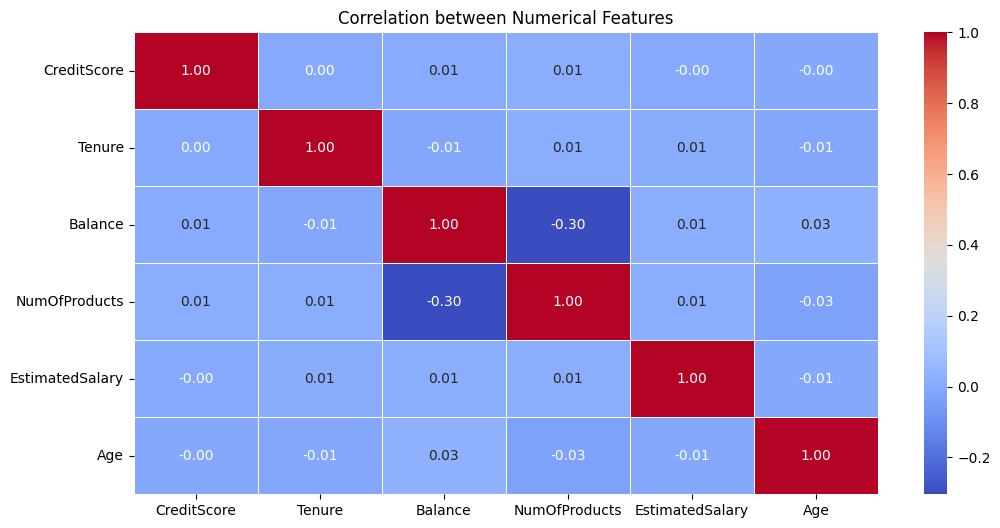

In [16]:
plt.figure(figsize=(12,6))
col=num_col
corr=df[col].corr()
sns.heatmap(corr, annot=True, fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation between Numerical Features")

plt.show()

### Scatter PLot between balance vs Num of Products

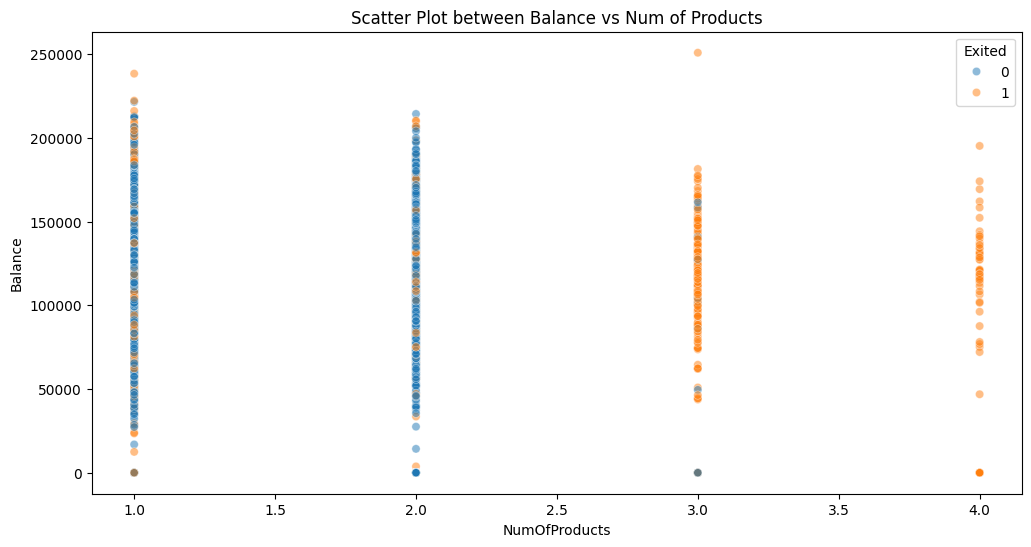

In [17]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='NumOfProducts',y='Balance',hue="Exited",alpha=0.5)
plt.title("Scatter Plot between Balance vs Num of Products")
plt.show()

### Scatter Plot: Balance vs NumOfProducts

The scatter plot shows the relationship between customer balance and the number of bank products used, separated by churn status. Most customers have either 1 or 2 products, and both churned and non-churned customers are found in these groups.

However, customers with 3 or 4 products show a higher concentration of churned customers. This suggests that customers using more bank products are not always more loyal; in this dataset, customers with 3 or 4 products appear more likely to exit.

Balance values are spread across different product groups, so balance alone does not clearly separate churned and non-churned customers. However, the combination of Balance and NumOfProducts may be useful for predicting customer churn.

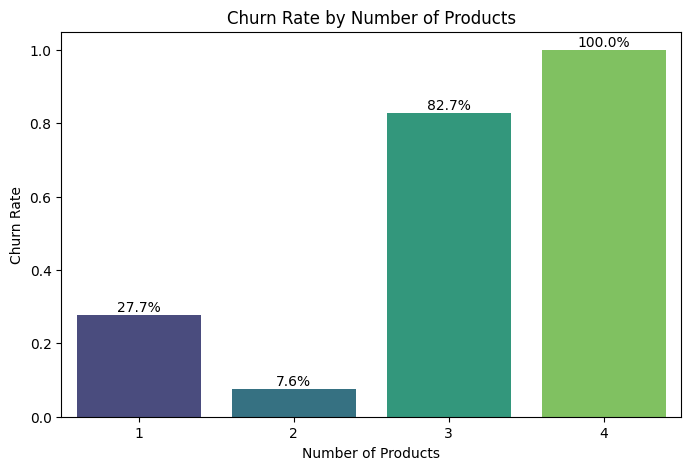

In [18]:


# Calculate churn rate
churn_rate = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=churn_rate,
    x='NumOfProducts',
    y='Exited',
    palette='viridis'
)

plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Number of Products')

# Add percentage labels on bars
for i, value in enumerate(churn_rate['Exited']):
    plt.text(
        i,
        value + 0.01,
        f'{value * 100:.1f}%',
        ha='center'
    )

plt.show()

### Features Engineeering
Feature engineering is the process of using domain knowledge to select, create, and transform raw data into informative features (variables) that improve machine learning model accuracy and performance.

is the art of introducing new features that werenot existing before so we will add balance per product, age group , BalanceSalaryRatio, remove columns cutomer id and surname 

In [19]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [20]:
df_fea=df.copy()

df_fea['balancePerProduct']=df_fea['Balance']/df_fea['NumOfProducts'].replace(0,np.nan)
df_fea['balancePerProduct'].fillna(0,inplace=True)


bins=[0,25,35,45,55,65,100]
labels=['<25','25 to 34','35 to 44','45 to 54','55 to 64','65+']
df_fea['age_group']=pd.cut(df_fea['Age'],bins=bins,labels=labels)


df_fea['BalanceSalaryRatio']=df_fea['Balance']/(df_fea['EstimatedSalary'].replace(0,np.nan))
df_fea['BalanceSalaryRatio'].replace(([np.inf,-np.inf]),np.nan, inplace=True)
df_fea['BalanceSalaryRatio'].fillna(df_fea['BalanceSalaryRatio'].median(),inplace=True)

df_fea['Tenure_period']=pd.cut(df_fea['Tenure'],bins=[-1,0,2,5,10,100],labels=['0','1-2','3-5','6-10','12+'])

df_fea[['balancePerProduct','age_group','BalanceSalaryRatio','Tenure_period']].head()
df_fea =df_fea.drop(['CustomerId','Surname'],axis=1)


### Preprocessing encoding scales

In [21]:

drop_Col=['CustomerId','Surname']



numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary',
    'balancePerProduct',
    'BalanceSalaryRatio'
]

categorical_features = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember',
    'age_group',
    'Tenure_period'
]

df_fea[categorical_features]=df_fea[categorical_features].astype('object')


#pipeline

numerical_transformer=Pipeline([("imputer",SimpleImputer(strategy='median')),
                       ("scaler",StandardScaler())])

categorical_transformer=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
                                  ('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
                                  ])

preprocessor=ColumnTransformer([
    ('num',numerical_transformer,numeric_features),
    ('cat',categorical_transformer,categorical_features)
])
df_fea.columns


Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'balancePerProduct', 'age_group', 'BalanceSalaryRatio',
       'Tenure_period'],
      dtype='object')

### Preprocessing Pipeline: Encoding and Scaling

A preprocessing pipeline was created to prepare the dataset before model training. The dataset contains both numerical and categorical features, so different preprocessing steps were applied to each type of feature.

For numerical features such as `CreditScore`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `EstimatedSalary`, `balancePerProduct`, and `BalanceSalaryRatio`, missing values were handled using `SimpleImputer` with the median strategy. After that, `StandardScaler` was applied to scale the numerical values into a similar range.

For categorical features such as `Geography`, `Gender`, `HasCrCard`, `IsActiveMember`, `age_group`, and `Tenure_period`, missing values were filled using the most frequent value. Then, `OneHotEncoder` was used to convert categorical variables into numerical form so that machine learning models could understand them.

The `ColumnTransformer` was used to combine both numerical and categorical preprocessing steps into one preprocessing object. This makes the workflow cleaner and helps prevent data leakage because preprocessing is fitted only on the training data during model training.

### Target features
 ### split data

In [22]:
X=df_fea.drop(['Exited'],axis=1)
y=df_fea['Exited']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print(X_train.shape)
print(X_test.shape)

(8000, 14)
(2000, 14)


### Train multiple model with a pipeline and compare usinf CV

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [24]:
models={
    'LogisticRegression':LogisticRegression(max_iter=500),
    'RandomForest':RandomForestClassifier(n_estimators=200,random_state=42),
    'GradientBoosting':GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost':AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC':SVC(probability=True,random_state=42)
}

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results={}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    scores=cross_val_score(pipe, X_train,y_train,cv=cv,scoring='roc_auc',n_jobs=-1)
    results[name]=scores
    print(f"{name} AUC: Mean= {scores.mean():.4f} Std= {scores.std():.4f}")



LogisticRegression AUC: Mean= 0.7879 Std= 0.0241
RandomForest AUC: Mean= 0.8479 Std= 0.0139
GradientBoosting AUC: Mean= 0.8619 Std= 0.0091
AdaBoost AUC: Mean= 0.8416 Std= 0.0135
SVC AUC: Mean= 0.8299 Std= 0.0097


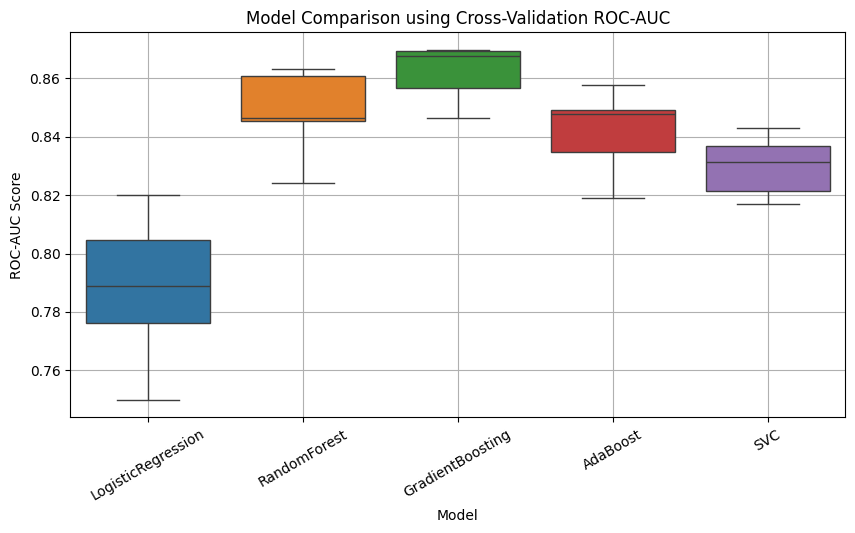

In [25]:
# Convert results dictionary into DataFrame
auc_df = pd.DataFrame(results)
auc_df


plt.figure(figsize=(10, 5))

sns.boxplot(data=auc_df)

plt.title('Model Comparison using Cross-Validation ROC-AUC')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=30)
plt.grid()
plt.show()

### Model Comparison Using Cross-Validation ROC-AUC

This boxplot compares different models using ROC-AUC scores from cross-validation. GradientBoosting achieved the highest ROC-AUC score and showed stable performance across folds, making it the best model for this project. RandomForest and AdaBoost also performed well, while LogisticRegression had the lowest score.

Since ROC-AUC measures how well the model separates churned and non-churned customers, GradientBoosting was selected as the final model for customer churn prediction.

### Finding Best MOdel

In [26]:
best_model = max(results, key=lambda model: results[model].mean())
best_score = results[best_model].mean()

print(f"Best Model: {best_model}")
print(f"Best Mean AUC: {best_score:.4f}")

Best Model: GradientBoosting
Best Mean AUC: 0.8619


### Finding the Best Model

After comparing all models using cross-validation ROC-AUC scores, the best model was selected based on the highest average ROC-AUC score. The result showed that **GradientBoosting** achieved the best mean ROC-AUC score of **0.8619**.

ROC-AUC was used because this is a customer churn classification problem, and the dataset is imbalanced. Accuracy alone may not fully show how well the model separates churned and non-churned customers.

Since GradientBoosting achieved the highest mean ROC-AUC score among the tested models, it was selected as the final model for further evaluation and prediction.

### Evalute Metrics

In [27]:

# Get best model object from models dictionary
best_model = models[best_model]

# Create final pipeline
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Train final model
best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC-AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8635
Test Precision: 0.7617
Test Recall: 0.4791
Test F1 Score: 0.5882
Test ROC-AUC: 0.8705

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



### Final Model Evaluation

The final model achieved **86.35% accuracy** and **87.05% ROC-AUC** on the test dataset, showing strong overall performance. The model performed very well in predicting non-churned customers, with high recall for class `0`.

For churned customers, the model achieved **76.17% precision** but only **47.91% recall**. This means that when the model predicts churn, it is often correct, but it still misses some customers who actually churned.



### Confusion Matrix

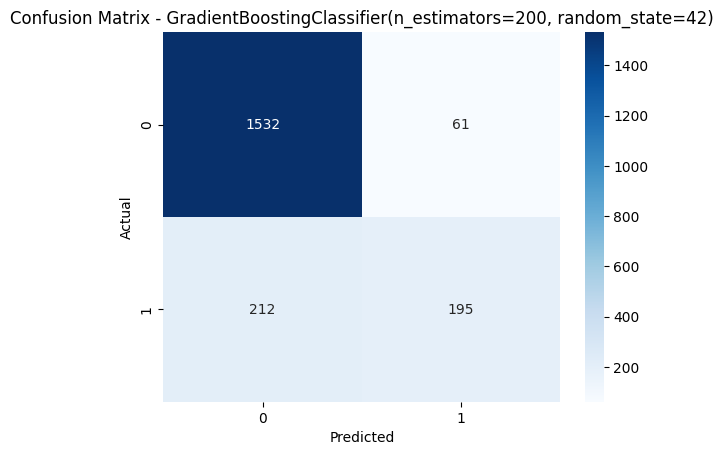

In [28]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model}')
plt.show()

### Confusion Matrix

The confusion matrix shows the prediction performance of the final model. The model correctly predicted **1532 non-churned customers** and **195 churned customers**. However, it incorrectly predicted **61 non-churned customers as churned** and missed **212 churned customers**, predicting them as non-churned.


### Features Importances

Age                   0.332279
NumOfProducts         0.265911
IsActiveMember_0      0.058831
Balance               0.050868
balancePerProduct     0.050152
Geography_Germany     0.049751
IsActiveMember_1      0.043823
BalanceSalaryRatio    0.038689
EstimatedSalary       0.031461
CreditScore           0.026287
age_group_45 to 54    0.014800
Gender_Female         0.006965
Gender_Male           0.006199
Tenure                0.005671
age_group_55 to 64    0.005473
Geography_France      0.003457
age_group_35 to 44    0.003437
Tenure_period_3-5     0.001369
Tenure_period_0       0.001338
HasCrCard_0           0.001272
dtype: float64

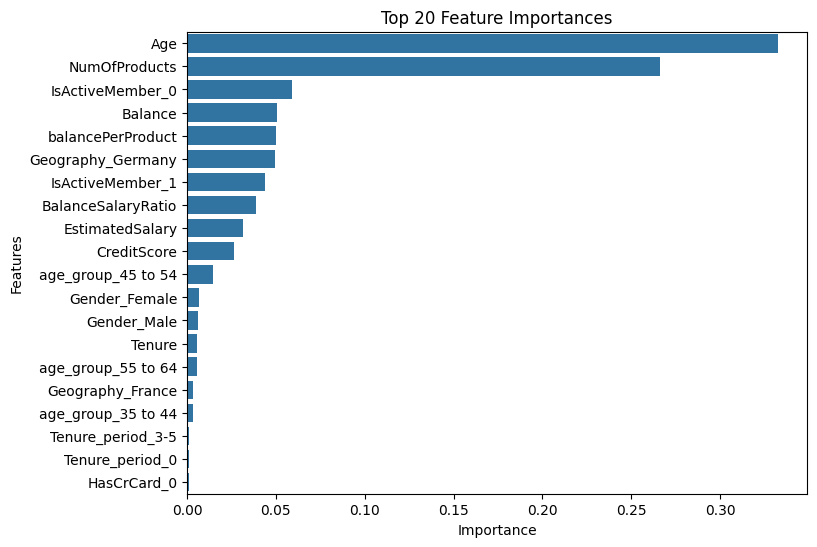

In [29]:

if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):

    # Numerical feature names
    num_feats = numeric_features

    # Categorical feature names after OneHotEncoding
    cat_feats = list(
        best_pipeline.named_steps['preprocessor']
        .transformers_[1][1]
        .named_steps['onehot']
        .get_feature_names_out(categorical_features)
    )

    # Combine all feature names
    feature_names = num_feats + cat_feats

    # Get feature importance values
    importances = best_pipeline.named_steps['classifier'].feature_importances_

    # Create dataframe
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]

    # Display top 20 feature importance
    display(fi)

    # Plot feature importance
    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Top 20 Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.show()

else:
    print("Selected model does not provide feature_importances_ attribute.")

### Top 20 Feature Importances

The feature importance chart shows which variables contributed the most to the customer churn prediction model. In this model, **Age** is the most important feature, meaning customer age has the strongest influence on predicting whether a customer will leave the bank or not.

The second most important feature is **NumOfProducts**, which shows that the number of bank products used by a customer has a strong relationship with churn. This matches the earlier EDA, where customers with 3 or 4 products showed a higher churn tendency.

Other important features include **IsActiveMember**, **Balance**, **balancePerProduct**, **Geography_Germany**, and **BalanceSalaryRatio**. This suggests that customer activity, account balance, country, and balance-related ratios are useful for identifying churn risk.

Features such as **HasCrCard**, **Tenure_period**, and some age groups have lower importance, meaning they contributed less to the model’s prediction compared to the top features.

Overall, the feature importance result shows that the model mainly relies on customer age, product usage, activity status, balance, and geography to predict churn.

### Saving the best Pipeline  and preprocessing artifacts
means you are saving your trained model workflow into a file so you can use it later without training again.

In [30]:
import joblib

joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl


In [31]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Sample Test

In [32]:
# New customer sample
sample = [
    {
        'Customer_Id': 11111111,
        'CreditScore': 650,
        'Geography': 'France',
        'Gender': 'Male',
        'Age': 40,
        'Tenure': 3,
        'Balance': 50000,
        'NumOfProducts': 2,
        'HasCrCard': 1,
        'IsActiveMember': 1,
        'EstimatedSalary': 60000
    },
    {
        'Customer_Id': 21111111,
        'CreditScore': 100,
        'Geography': 'France',
        'Gender': 'Female',
        'Age': 19,
        'Tenure': 1,
        'Balance': 10000000,
        'NumOfProducts': 1,
        'HasCrCard': 1,
        'IsActiveMember': 1,
        'EstimatedSalary': 600000000
    },
    {
    'Customer_Id': 22111111,
    'CreditScore': 580,
    'Geography': 'Germany',
    'Gender': 'Female',
    'Age': 50,
    'Tenure': 1,
    'Balance': 130000,
    'NumOfProducts': 3,
    'HasCrCard': 1,
    'IsActiveMember': 0,
    'EstimatedSalary': 90000
}
]

# Convert list of dictionaries to dataframe
sample_df = pd.DataFrame(sample)

# Save Customer_Id before dropping it
customer_ids = sample_df['Customer_Id']

# Apply same feature engineering as training data
sample_df['balancePerProduct'] = sample_df['Balance'] / sample_df['NumOfProducts'].replace(0, np.nan)
sample_df['balancePerProduct'] = sample_df['balancePerProduct'].fillna(0)

sample_df['BalanceSalaryRatio'] = sample_df['Balance'] / sample_df['EstimatedSalary'].replace(0, np.nan)
sample_df['BalanceSalaryRatio'] = sample_df['BalanceSalaryRatio'].replace([np.inf, -np.inf], np.nan)
sample_df['BalanceSalaryRatio'] = sample_df['BalanceSalaryRatio'].fillna(sample_df['BalanceSalaryRatio'].median())

bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25 to 34', '35 to 44', '45 to 54', '55 to 64', '65+']

sample_df['age_group'] = pd.cut(
    sample_df['Age'],
    bins=bins,
    labels=labels
)

sample_df['Tenure_period'] = pd.cut(
    sample_df['Tenure'],
    bins=[-1, 2, 5, 10],
    labels=['0-2', '3-5', '6-10']
)

# Drop Customer_Id before prediction
sample_df = sample_df.drop(columns=['Customer_Id'])

# Predict churn for all customers
predictions = best_pipeline.predict(sample_df)

# Predict churn probability for all customers
probabilities = best_pipeline.predict_proba(sample_df)[:, 1]

# Final output with Customer_Id
output = pd.DataFrame({
    'Customer_Id': customer_ids,
    'Prediction': predictions,
    'Churn_Probability': probabilities
})

# Convert 0 and 1 into readable result
output['Result'] = output['Prediction'].map({
    0: 'Not Churn / Likely to Stay',
    1: 'Churn / Likely to Leave'
})

output

,Customer_Id,Prediction,Churn_Probability,Result
0,11111111,0,0.046858,Not Churn / Likely to Stay
1,21111111,1,0.961862,Churn / Likely to Leave
2,22111111,1,0.963052,Churn / Likely to Leave


### Why Pipeline Was Used

A pipeline was used to combine preprocessing and model training into one complete workflow. The numerical pipeline handled missing values and scaling for numerical features, while the categorical pipeline handled missing values and one-hot encoding for categorical features. These preprocessing steps were combined using ColumnTransformer.

The final pipeline combined the preprocessor with the machine learning model. This approach helps prevent data leakage because preprocessing is fitted only on the training data. It also makes the workflow cleaner and easier to reuse for new customer predictions, because the same preprocessing steps are automatically applied before prediction.
